In [255]:
import datetime as dt
import joblib
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import pandas as pd
import pathlib
import pymoo
import sklearn
import xgboost as xgb

# import some one offs
from multiprocessing.pool import ThreadPool
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.problem import StarmapParallelization
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from typing import *


In [2]:
%load_ext autoreload
%autoreload 2

In [221]:
#####################
#    SET GLOBALS    #
#####################

# fields
_FIELD_FUTURE_ID = "future_id"
_FIELD_PRIMARY_ID = "primary_id"
_FIELD_PARETO_INDEX = "pareto_index"
_FIELD_TRAJGROUP = "variable_trajectory_group"

# file names
_FILE_NAME_DATA_TRAINING = "training_data_v5.3.csv"
_FILE_NAME_MODEL = "xgb_pipeline_5.3.pkl"
_FILE_NAME_TRAJGROUPS_L = "VARIABLE_TRAJECTORY_GROUPS_L.csv"
_FILE_NAME_TRAJGROUPS_X = "VARIABLE_TRAJECTORY_GROUPS_X.csv"

# set some paths
_PATH_SCRIPT = pathlib.Path(os.getcwd())
_PATH_ROOT = _PATH_SCRIPT.parents[0]
_PATH_DATA = _PATH_ROOT.joinpath("data")
_PATH_DATA_MAPPING = _PATH_DATA.joinpath("mapping")
_PATH_DATA_TRAINING = _PATH_DATA.joinpath("training")
_PATH_TRAINED_MODELS = _PATH_SCRIPT.joinpath("trained_models")



########################
#    SOME FUNCTIONS    #
########################

def get_model(
    fn: str = _FILE_NAME_MODEL,
) -> pd.DataFrame:
    """Get and prepare training data that was used to train the model
    """
    # set the read path
    path_model = _PATH_TRAINED_MODELS.joinpath(fn)
    xgb_pipeline = None
    
    try:
        xgb_pipeline = joblib.load(path_model)
        
    except Exception as e:
        raise RuntimeError(f"Unable to read xgb_pipeline at path '{path_model}': {e}")

    return xgb_pipeline



def get_training_data(
    fn: str = _FILE_NAME_DATA_TRAINING,
) -> pd.DataFrame:
    """Get and prepare training data that was used to train the model.
        Returns a dictionary of the following form:

        {
            "df",                   # training DataFrame
            "fields_index",         # fields that index the dataframe
            "fields_x",             # labels for input features
            "fields_y",             # labels for output features
        }
    """
    # set the read path
    path_training_data = _PATH_DATA_TRAINING.joinpath(fn)

    # clean and convert net benefits to cost
    df_train = pd.read_csv(path_training_data)
    df_train = df_train.drop(columns = [_FIELD_PRIMARY_ID],)
    df_train["technical_cost"] *= -1

    
    ##  GET FIELD SETS
    
    fields_index = [_FIELD_FUTURE_ID]
    fields_index = [x for x in df_train.columns if x in fields_index]
    
    fields_y = [
        x for x in df_train.columns 
        if True
        and not x.startswith("group_") 
        and (x not in fields_index)
    ]
    
    fields_x = [
        x for x in df_train.columns 
        if x not in fields_index + fields_y
    ]


    # setup output
    dict_out = {
        "df": df_train,
        "fields_index": fields_index,
        "fields_x": fields_x,
        "fields_y": fields_y,
    }

    return dict_out



def get_trajgroups(
    fn_l: str = _FILE_NAME_TRAJGROUPS_L,
    fn_x: str = _FILE_NAME_TRAJGROUPS_X,
) -> Dict:
    """Get dataframes defining sample groups associated with Xs and those
        associated with Ls. Returns a dicitonary of the follwing form:

        {
            "df_l": pd.DataFrame,           # DataFrame of lever trajectory groups
            "df_x": pd.DataFrame,           # DataFrame of exogenous uncertainty trajectory groups
            "trajgroups_l": np.ndarray,     # Lever trajectory groups
            "trajgroups_x": np.ndarray      # Exogenous uncertainty trajectory groups
        }
    """
    # set paths
    path_l = _PATH_DATA_MAPPING.joinpath(fn_l)
    path_x = _PATH_DATA_MAPPING.joinpath(fn_x)

    # data frames
    df_l = pd.read_csv(path_l, )
    df_x = pd.read_csv(path_x, )

    # get trajectory groups
    trajgroups_l = df_l[_FIELD_TRAJGROUP].unique()
    trajgroups_x = df_x[_FIELD_TRAJGROUP].unique()

    # output dictionary
    out = {
        "df_l": df_l,
        "df_x": df_x,
        "trajgroups_l": trajgroups_l,
        "trajgroups_x": trajgroups_x,
    }

    return out


# retrieve 
dict_training_data = get_training_data()
dict_trajgroups = get_trajgroups()
xgb_pipeline = get_model()


In [228]:
# Predict using the trained model
predictions = xgb_pipeline.predict(
    np.array(
        [
            df_train[dict_training_data.get("fields_x")].iloc[0]
        ]
    )
)

print("Predictions for single row:")
for i, label in enumerate(dict_training_data.get("fields_y")):
    print(f"{label}: {predictions[0][i]:.4f}")



Predictions for single row:
emission_avg_last_five_years: 197.2722
emission_total: 6639.7114
production_total: 996680576.0000
production_cost_total: 12088548352.0000
technical_cost: 67.3792
air_pollution: 39.2917
consumer_savings: 11.0178
human_health: 7.4168


# Setup narrative profiles optimization

In [198]:



class NarrativePareto(ElementwiseProblem):
    """

    Intialization Arguments
    -----------------------
    labels_x : Union[List, np.ndarray]
        Order vector of input labels to model
    labels_y : Union[List, np.ndarray]

    Optional Arguments
    ------------------
    dict_fixed_inputs : Union[Dict[int, float], None]
        Optional specification of a dictionary of fixed values for inputs. 
        Maps the index in the input vector to a fixed value to maintain.
    inds_obj : Union[List, np.ndarray, None]
        Optional specification of indices in the output features to
        keep and optimize on. If None, searches for multi-dimensional 
        frontier associated with all outputs
    vec_obj_scalars : Union[List, np.ndarray, None]
        Optional scalars to apply to outputs. Must be same shape as
        output (i.e., if reducing using inds_obj, must be of same length)
    **kwargs : 
        Passed to super().__init__() (super => pymoo.Problem class)
    """
    
    def __init__(self,
        model: sklearn.pipeline.Pipeline,
        labels_x: Union[List, np.ndarray],
        labels_y: Union[List, np.ndarray],
        dict_fixed_inputs: Union[Dict[int, float], None] = None,
        inds_obj: Union[List, np.ndarray, None] = None,
        vec_obj_scalars: Union[List, np.ndarray, None] = None,
        **kwargs,
    ) -> None:

        self._initialize_model(model, )
        self._initialize_scalars(
            labels_x,
            labels_y,
            inds_obj,
            vec_obj_scalars,
            **kwargs,
        )

        self._initialize_fixed_inputs(
            dict_fixed_inputs,
        )
        
        
        return None


    

    ##################################
    #    INITIALIZATION FUNCTIONS    #
    ##################################

    def _initialize_fixed_inputs(self,
        dict_fixed_inputs: Union[Dict[int, float], None],
    ) -> None:
        """Check the model input and set property self.model
        """

        dict_fi = {}
        
        if isinstance(dict_fixed_inputs, dict):

            for k, v in dict_fixed_inputs.items():
                keep_q = isinstance(k, (int, np.int32, np.int64, ))
                keep_q &= isinstance(v, (int, np.int32, np.int64, float, np.float32, np.float64))
                keep_q &= k in range(self.n)
                
                if not keep_q: continue

                dict_fi.update({k: v})


        ##  SET PROPERTY
        
        self.dict_fixed_inputs = dict_fi

        return None


    
    def _initialize_model(self,
        model: sklearn.pipeline.Pipeline,
    ) -> None:
        """Check the model input and set property self.model
        """
        if not isinstance(model, sklearn.pipeline.Pipeline):
            tp = str(type(model))
            raise TypeError(f"Invalid type '{tp}' found for model. Must be of type sklearn.pipeline.Pipeline")


        self.model = model

        return None

    

    def _initialize_scalars(self,
        labels_x: Union[List, np.ndarray],
        labels_y: Union[List, np.ndarray],
        inds_obj: Union[List, np.ndarray, None],
        vec_obj_scalars: Union[List, np.ndarray, None],
        **kwargs,
    ) -> None:
        """Initialize scalars used in the problem
        """
        ##  INIT AND CONVERSION
        
        labels_x = np.array(labels_x, )
        labels_y_universe = np.array(labels_y, )

        # filter indices used in the objective function
        inds_obj = (
            np.arange(labels_y_universe.shape[0])
            if inds_obj is None
            else np.array(inds_obj).astype(int)
        )

        # check adjustments
        vec_obj_scalars = (
            np.array(vec_obj_scalars) 
            if vec_obj_scalars is not None 
            else vec_obj_scalars
        )
        
        vec_obj_scalars = (
            np.ones(inds_obj.shape, np.int64)
            if vec_obj_scalars is None
            else (
                np.ones(inds_obj.shape, np.int64)
                if vec_obj_scalars.shape != inds_obj.shape
                else vec_obj_scalars
            )
        )

        # finally, set labels
        labels_y = labels_y_universe[inds_obj]
        n = labels_x.shape[0]
        m = labels_y.shape[0]


        ##  PASS TO SUPER

        super().__init__(
            n_var = n,
            n_obj = m,
            n_ieq_constr = 0,
            xl = np.zeros(n),
            xu = np.ones(n),
            **kwargs,
        )


        ##  SET SOME PROPERTIES

        self.inds_obj = inds_obj
        self.labels_x = labels_x
        self.labels_y = labels_y
        self.labels_y_universe = labels_y_universe    # all y values
        self.m = m                                    # size of output feature space
        self.n = n                                    # size of input feature space
        self.vec_obj_scalars = vec_obj_scalars        # vector of scalars to multiply output predictions by (ordered by inds_obj)

        return None
    

    

    #########################
    #    CORE OPERATIONS    #
    #########################

    def build_input_vector(self,
        x: np.ndarray,
    ) -> np.ndarray:
        """Build the input vector for the XGBoost pipeline
        """

        for k, v in self.dict_fixed_inputs.items():
            x[k] = v

        out = np.array([x])
        
        return out


    
    def _evaluate(self,
        x: np.ndarray,
        out: dict,
        *args, 
        **kwargs,
    ) -> None:
        """This method is required for the pymoo.minimize() function
        """
        # treat any fixed inputs
        x_in = self.build_input_vector(x)
        
        # predict the outcome; both dimensions will be minimized
        arr = self.model.predict(x_in, )
        vec = arr[0, self.inds_obj]
        vec *= self.vec_obj_scalars
        
        out["F"] = vec

        return None




In [190]:
#?pymoo.core.problem.Problem
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [ ]:
# some parallelization code blocks
"""
# if __name__ == "__main__":
    
    # with mp.Pool(processes = 6, ) as pool:
    #     runner = StarmapParallelization(pool.starmap, )
    #     elementwise_runner = runner,    # add to NarrativePareto as kwarg
 
t0 = time.time()
#with ThreadPool(20, ) as pool:
#    runner = StarmapParallelization(pool.starmap, )

from dask.distributed import Client
from pymoo.core.problem import DaskParallelization
client = Client()
client.restart()
print("DASK STARTED")
runner = DaskParallelization(client)
"""

In [231]:
labels


['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'consumer_savings',
 'human_health']

In [244]:

def build_df_out(
    res: pymoo.core.result.Result,
    problem: NarrativePareto,
    dict_additional_fields: Union[Dict[str, Any], None] = None,
) -> pd.DataFrame:
    """Build an output dataframe
    """

    # initialize base DataFrame out
    df_base = pd.DataFrame(
        res.F,
        columns = problem.labels_y,
    )

    # add columns of interest
    df_base[_FIELD_PARETO_INDEX] = range(df_base.shape[0])
    if isinstance(dict_additional_fields, dict):
        for k, v in dict_additional_fields.items():
            if not isinstance(k, str): continue
            df_base[k] = v

    return df_base



def get_fixed_fields_ind_dict(
    dict_training_data: Dict[str, Any],
    dict_trajgroups: Dict[str, Any],
) -> Dict[str, int]:
    """Build dictionary mapping the field to the associated index
        in vector x. This is a slow, lazy way to do it, but it works.
    """

    # get training data
    df_train = dict_training_data.get("df")
    if not isinstance(df_train, pd.DataFrame):
        raise TypeError(f"DataFrame 'df' not found in dict_training_data")
    
    labels_x = dict_training_data.get("fields_x")
  
    # get fixed fields
    trajgroups_x = dict_trajgroups.get("trajgroups_x")
    fields_trajgroups_x = [
        x for x in df_train.columns 
        if any([x.startswith(f"group_{j}_") for j in trajgroups_x])
    ]
    
    dict_inds_fields_trajgroups_x = dict(
        (x, labels_x.index(x))
        for x in fields_trajgroups_x
    )

    return dict_inds_fields_trajgroups_x







##  SETUP THE ALGORITHM

algorithm = NSGA2(
    pop_size = 40,
    n_offsprings = 10,
    sampling = FloatRandomSampling(),
    crossover = SBX(prob = 0.9, eta = 15),
    mutation = PM(eta = 20),
    eliminate_duplicates = True,
)



##  INITIALIZE OUTPUT


# used to map fixed values to problem
dict_inds_fields_trajgroups_x = get_fixed_fields_ind_dict(
    dict_training_data,
    dict_trajgroups,
)

# initialize output from the iteration
df_pareto_frontiers = []
dict_res = {}


t0 = time.time()

with ThreadPool(30, ) as pool:

    runner = StarmapParallelization(pool.starmap, )
    
    for i, row in df_train.iloc[0:2].iterrows():
    
        print(f"Starting row {i}...")

        future_id = int(row[_FIELD_FUTURE_ID])
        
        # get inputs
        dict_fixed_inputs = row[fields_trajgroups_x].to_dict()
        dict_fixed_inputs = dict(
            (dict_inds_fields_trajgroups_x.get(k), v)
            for k, v in dict_fixed_inputs.items()
        )
    
        # setup the problem
        problem = NarrativePareto(
            xgb_pipeline,
            dict_training_data.get("fields_x"),
            dict_training_data.get("fields_y"),
            dict_fixed_inputs = dict_fixed_inputs,
            inds_obj = [0, 4],                       # indices of output values to actually optimize on
            vec_obj_scalars = np.array([1, -1]),     # scalars to apply to output values (ordered same as inds_obj)
            elementwise_runner = runner,             # use this to parallelize (doesn't work that well--not sure why I can't pass directly to NSGA())
        )
    
        # 
        res = minimize(
            problem,
            algorithm,
            ('n_gen', 1000),
            verbose = False,
        )

        # get the output dataframe
        df_cur = build_df_out(
            res,
            problem,
            dict_additional_fields = {
                _FIELD_FUTURE_ID: future_id, 
            }
        )

        # append to outputs
        df_pareto_frontiers.append(df_cur, )
        dict_res.update({i: res, })

        
        print(f"Row {i} done.\n\n")


df_pareto_frontiers = (
    pd.concat(df_pareto_frontiers)
    .reset_index(drop = True)
)

t1 = time.time()        




Starting row 0...
Row 0 done.


Starting row 1...
Row 1 done.




In [246]:
df_pareto_frontiers

,emission_avg_last_five_years,technical_cost,pareto_index,future_id
0,151.735245,-140.306412,0,1
1,108.268402,-72.610542,1,1
2,151.735245,-140.306412,2,1
3,122.960152,-112.154610,3,1
4,112.411392,-93.778511,4,1
...,...,...,...,...
75,109.350143,-82.527397,35,2
76,126.023933,-99.677757,36,2
77,99.802582,-57.514450,37,2
78,105.653091,-75.307785,38,2


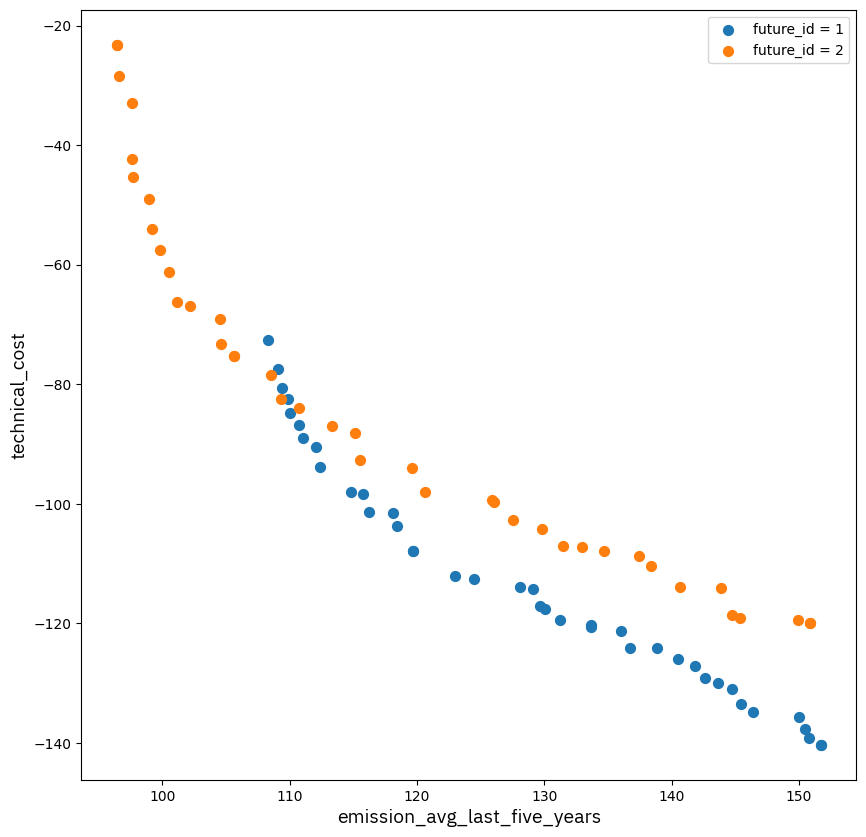

In [253]:
fig, ax = plt.subplots(figsize = (10, 10))

# get labels
labels_y = problem.labels_y
ax.set_xlabel(labels_y[0], fontfamily = "IBM Plex Sans", fontsize = 14, )
ax.set_ylabel(labels_y[1], fontfamily = "IBM Plex Sans", fontsize = 14, )


dfg = df_pareto_frontiers.groupby([_FIELD_FUTURE_ID])
for fut, df in dfg:
    
    ax.scatter(
        df[labels_y[0]], 
        df[labels_y[1]], 
        #facecolor = "none",
        #edgecolor = "red",
        label = f"{_FIELD_FUTURE_ID} = {fut[0]}",
        s = 50,
    )

ax.legend()


# Export

In [268]:
##  SOME BASIC NAMING FUNCTIONS

def get_date(
) -> str:
    """Get date to use as suffix
    """
    now = dt.datetime.now()
    
    year = str(now.year).rjust(4, "0")
    month = str(now.month).rjust(2, "0")
    day = str(now.day).rjust(2, "0")

    out = f"{year}{month}{day}"

    return out



def get_fn_out(
) -> str:
    """Get the name of the file to export
    """
    date = get_date()
    out = f"xgb_pymoo_pareto_front_{date}.csv"
    return out



##  CHECK PATH AND WRITE

path_out = pathlib.Path(os.getcwd()).parents[0].joinpath("optimization", "out")
if not path_out.is_dir():
    path_out.mkdir(exist_ok = True, )

df_pareto_frontiers.to_csv(
    path_out.joinpath(get_fn_out()),
    encoding = "UTF-8",
    index = None,
)




